In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("iphone_sales.csv")
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817,01-05-2025,Debit Card
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998,05-03-2025,PayPal
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876,25-01-2025,Credit Card
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290,24-03-2025,Debit Card
4,1005,Customer_5,USA,iPhone 15,128GB,Blue,3,"df = pd.read_excel(""iphone_sales.xlsx"")",01-02-2025,Debit Card


In [6]:
df.isnull().sum()

Order_ID          0
Customer_Name     0
Country           0
iPhone_Model      0
Storage           0
Color             0
Quantity          0
Price             0
Sale_Date         0
Payment_Method    0
dtype: int64

In [7]:
# Convert Price column to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Remove invalid Price values
df = df.dropna(subset=["Price"])

print("Updated Shape:", df.shape)

Updated Shape: (99, 10)


In [8]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], dayfirst=True)
df.head()

,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817.0,2025-05-01,Debit Card
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998.0,2025-03-05,PayPal
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876.0,2025-01-25,Credit Card
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290.0,2025-03-24,Debit Card
5,1006,Customer_6,UAE,iPhone 14 Pro,256GB,Red,5,1939.0,2025-02-15,Debit Card


In [9]:
df["Revenue"] = df["Quantity"] * df["Price"]
df.head()

,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method,Revenue
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817.0,2025-05-01,Debit Card,9085.0
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998.0,2025-03-05,PayPal,998.0
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876.0,2025-01-25,Credit Card,4380.0
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290.0,2025-03-24,Debit Card,2580.0
5,1006,Customer_6,UAE,iPhone 14 Pro,256GB,Red,5,1939.0,2025-02-15,Debit Card,9695.0


In [10]:
revenue = np.array(df["Revenue"])
print("Mean Revenue :", np.mean(revenue))
print("Maximum Revenue :", np.max(revenue))
print("Minimum Revenue :", np.min(revenue))
print("Median Revenue :", np.median(revenue))
print("Standard Deviation :", np.std(revenue))

Mean Revenue : 4961.383838383838
Maximum Revenue : 9960.0
Minimum Revenue : 733.0
Median Revenue : 5013.0
Standard Deviation : 2656.071435189519


In [11]:
country_sales = df.groupby("Country")["Revenue"].sum()
country_sales.sort_values(ascending=False)

Country
UK          117705.0
USA         111539.0
Canada       84091.0
UAE          77898.0
Germany      53334.0
Pakistan     46610.0
Name: Revenue, dtype: float64

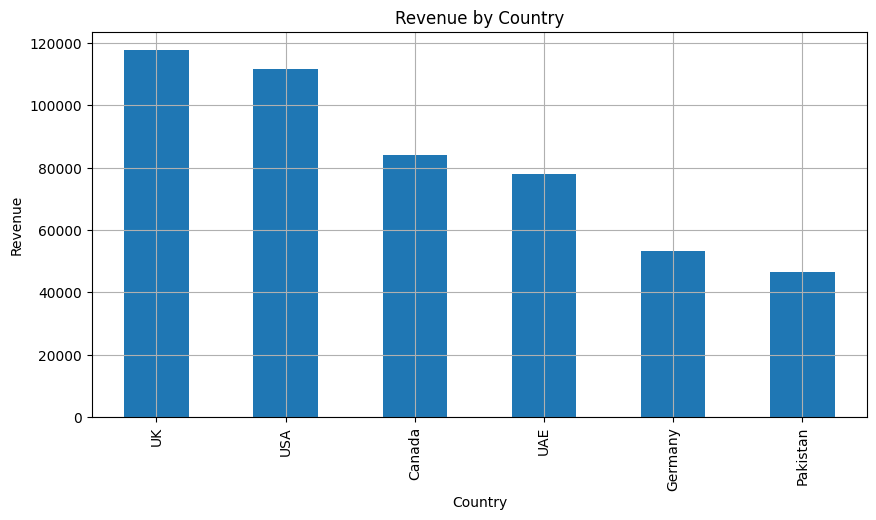

In [12]:
country_sales.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [13]:
model_sales = df.groupby("iPhone_Model")["Revenue"].sum()
model_sales.sort_values(ascending=False)

iPhone_Model
iPhone 14 Pro        105490.0
iPhone 15 Pro Max    101076.0
iPhone 13             90268.0
iPhone 15             76667.0
iPhone 12             63491.0
iPhone 14             54185.0
Name: Revenue, dtype: float64

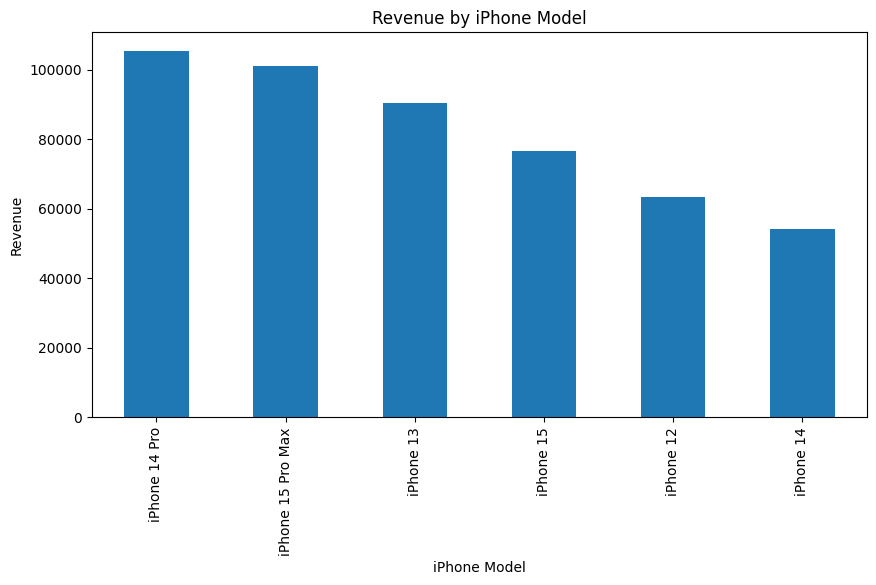

In [14]:
model_sales.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Revenue")

plt.show()

In [15]:
payment_method = df["Payment_Method"].value_counts()
payment_method

Payment_Method
Debit Card     37
Credit Card    25
Cash           19
PayPal         18
Name: count, dtype: int64

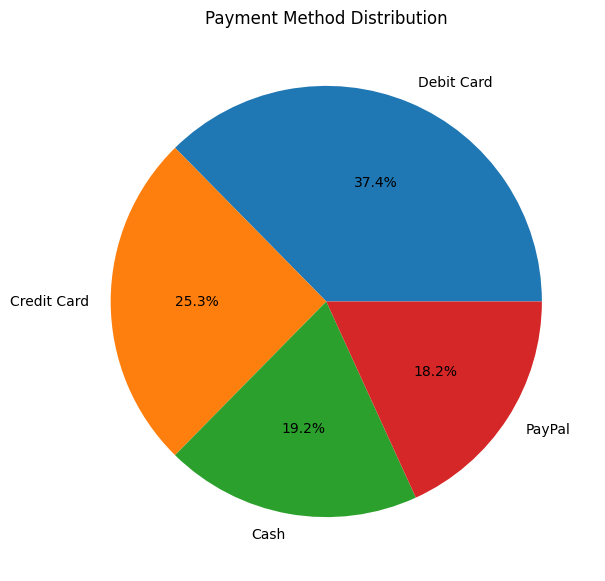

In [19]:
payment_method.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.show()

In [21]:
df["Month"] = df["Sale_Date"].dt.month_name()

monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales

Month
April        99945.0
February     99918.0
January     160408.0
March       116740.0
May          14166.0
Name: Revenue, dtype: float64

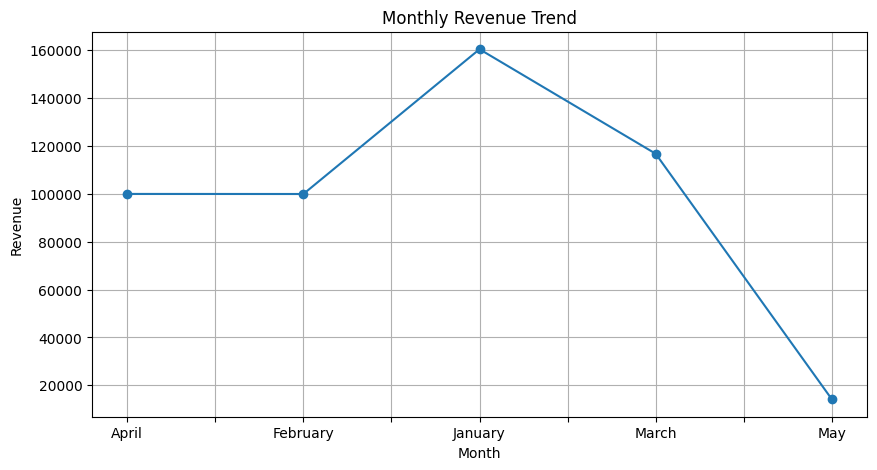

In [22]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [23]:
best_model = df.groupby("iPhone_Model")["Quantity"].sum()

print("Best Selling Model:")
print(best_model.sort_values(ascending=False))

Best Selling Model:
iPhone_Model
iPhone 15 Pro Max    73
iPhone 14 Pro        66
iPhone 13            59
iPhone 15            54
iPhone 12            42
iPhone 14            36
Name: Quantity, dtype: int64


In [24]:
top5_countries = country_sales.sort_values(
    ascending=False
).head(5)

print(top5_countries)

Country
UK         117705.0
USA        111539.0
Canada      84091.0
UAE         77898.0
Germany     53334.0
Name: Revenue, dtype: float64


In [25]:
print("========== BUSINESS INSIGHTS ==========")

print("\nTotal Revenue:")
print(df["Revenue"].sum())

print("\nAverage Revenue:")
print(df["Revenue"].mean())

print("\nHighest Revenue Country:")
print(country_sales.idxmax())

print("\nBest Selling iPhone Model:")
print(best_model.idxmax())

print("\nMost Preferred Payment Method:")
print(df["Payment_Method"].value_counts().idxmax())

========== BUSINESS INSIGHTS ==========

Total Revenue:
491177.0

Average Revenue:
4961.383838383838

Highest Revenue Country:
UK

Best Selling iPhone Model:
iPhone 15 Pro Max

Most Preferred Payment Method:
Debit Card
